In [1]:
from transformers import pipeline
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

/opt/anaconda3/envs/NLP/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
vocab = {"hello": 0, "i": 1, "am": 2, "chatgpt": 3, "world": 4}
vocab_size = len(vocab)
embedding_dim = 10
hidden_dim = 20
vocab_size

5

In [13]:
sentence = "Hello world I ChatGPT"
tokens = sentence.lower().split()
token_ids = torch.tensor([vocab[token] for token in tokens], dtype=torch.long)
token_ids

tensor([0, 4, 1, 3])

In [14]:
embedding = nn.Embedding(vocab_size, embedding_dim)
embedded = embedding(token_ids)
embedded.shape

torch.Size([4, 10])

In [32]:
class Classifier(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super().__init__()
        self.layer = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        x = x.mean(dim=0)
        return x

In [33]:
model = Classifier(vocab_size, 2)
output = model(embedded)
output

tensor([ 0.1251,  0.0348, -0.3520, -0.5570, -0.5014,  0.5813, -0.0009,  0.0860,
        -0.7946,  0.6028], grad_fn=<MeanBackward1>)

In [38]:
probs = F.softmax(output, dim=0)
probs

tensor([0.1110, 0.1014, 0.0689, 0.0561, 0.0593, 0.1752, 0.0979, 0.1068, 0.0443,
        0.1790], grad_fn=<SoftmaxBackward0>)

In [40]:
a = torch.zeros(size=(3,5 ), dtype=torch.int32)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [117]:
import string
chars = string.ascii_lowercase
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
stoi['<S>'] = 26
itos[26] = '<S>'
stoi['<E>'] = 27
itos[27] = '<E>'
len(stoi), len(itos)

(28, 28)

In [118]:
N = torch.zeros(size=(28, 28 ), dtype=torch.int32)

In [148]:
for w in ['hello', 'world', 'i', 'am', 'gerald',
          'and', 'gerald', 'is', 'using', 'torch',
          'to', 'build', 'a', 'character', 'model',
          'also', 'giovanna', 'is', 'my', 'daughter',
          'and', 'she', 'is', 'very', 'cute', 'also',
          'my', 'wife', 'is', 'a', 'loving', 'person',
          'she','takes', 'care', 'of', 'me', 'and', 'our',
          'family','we', 'enjoy', 'spending', 'time', 'together',
          'for', 'some', 'reasons', 'i', 'need', 'to', 'query', 'this']:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

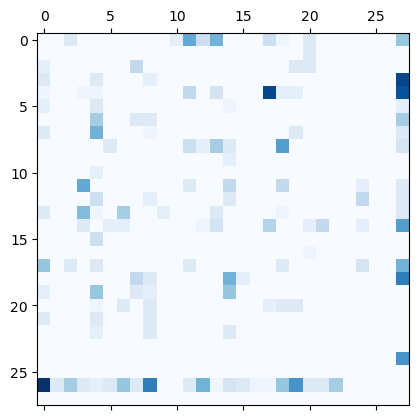

In [149]:
import matplotlib.pyplot as plt
plt.matshow(N.numpy(), cmap='Blues');

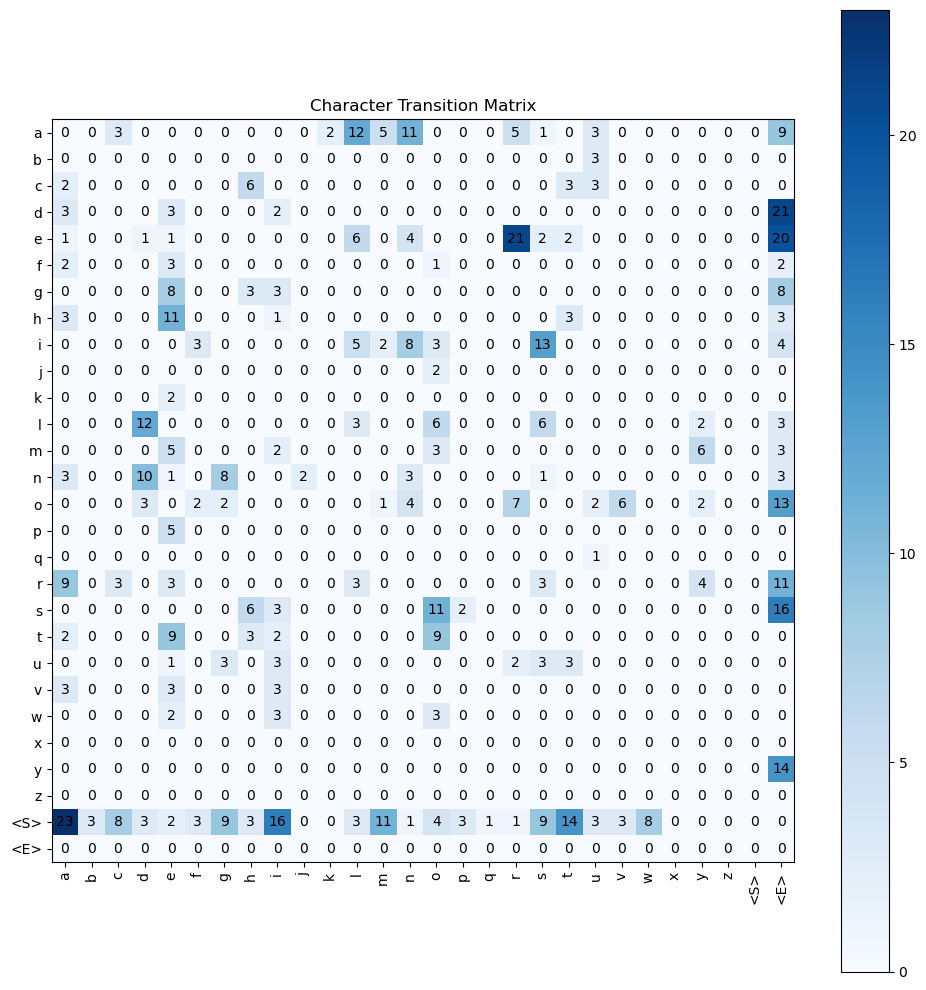

In [150]:
plt.figure(figsize=(10, 10))
plt.imshow(N.numpy(), cmap='Blues')
for i in range(N.shape[0]):
    for j in range(N.shape[1]):
        plt.text(j, i, N[i, j].item(), ha='center', va='center', color='black')
plt.xticks(range(len(itos)), itos.values(), rotation=90)
plt.yticks(range(len(itos)), itos.values())
plt.colorbar()
plt.title('Character Transition Matrix')
plt.tight_layout()
plt.show()

In [151]:
N[0]

tensor([ 0,  0,  3,  0,  0,  0,  0,  0,  0,  0,  2, 12,  5, 11,  0,  0,  0,  5,
         1,  0,  3,  0,  0,  0,  0,  0,  0,  9], dtype=torch.int32)

In [152]:
p = N[0].float() / N[0].sum()
p

tensor([0.0000, 0.0000, 0.0588, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0392, 0.2353, 0.0980, 0.2157, 0.0000, 0.0000, 0.0000, 0.0980,
        0.0196, 0.0000, 0.0588, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.1765])

In [153]:
ix = torch.multinomial(p, num_samples=1).item()
print(itos[ix])

m


In [154]:
P.sum(dim=0, keepdim=True)

tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan]])

In [160]:
N

tensor([[ 0,  0,  3,  0,  0,  0,  0,  0,  0,  0,  2, 12,  5, 11,  0,  0,  0,  5,
          1,  0,  3,  0,  0,  0,  0,  0,  0,  9],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  3,  0,  0,  0,  0,  0,  0,  0],
        [ 2,  0,  0,  0,  0,  0,  0,  6,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  3,  3,  0,  0,  0,  0,  0,  0,  0],
        [ 3,  0,  0,  0,  3,  0,  0,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0, 21],
        [ 1,  0,  0,  1,  1,  0,  0,  0,  0,  0,  0,  6,  0,  4,  0,  0,  0, 21,
          2,  2,  0,  0,  0,  0,  0,  0,  0, 20],
        [ 2,  0,  0,  0,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  2],
        [ 0,  0,  0,  0,  8,  0,  0,  3,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  8],
        [ 3,  0,  0,  0, 11,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
  

In [161]:
P = N.float() / N.sum(dim=1, keepdim=True)
P

tensor([[0.0000, 0.0000, 0.0588, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0392, 0.2353, 0.0980, 0.2157, 0.0000, 0.0000, 0.0000, 0.0980,
         0.0196, 0.0000, 0.0588, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.1765],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.1429, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4286, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.2143, 0.2143, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.1034, 0.0000, 0.0000, 0.0000, 0.1034, 0.0000, 0.0000, 0.0000, 0.0690,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [158]:
g = torch.Generator().manual_seed(42)

for i in range(10):
    ix = 26 # Start with the start token '<S>'
    out = []
    while True:
        p = N[ix].float() / N[ix].sum()
        ix = torch.multinomial(p, num_samples=1, generator=g, replacement=True).item()
        out.append(itos[ix])
        if ix == stoi['<E>']:
            break
    print(''.join(out))  # Exclude start and end tokens

ane<E>
anjomercuterspe<E>
etaker<E>
ter<E>
vis<E>
sovilsovilo<E>
miorer<E>
methary<E>
m<E>
andacuio<E>
